In [17]:
# Lesson 2 of the missing semester
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [18]:
# load spatial data
adata = sc.datasets.visium_sge()
adata.var_names_make_unique() # optional but good practice

sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor='seurat',
                            n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]

/tmp/ipykernel_85844/3051886893.py:2: FutureWarning: Use `squidpy.datasets.visium` instead.
  adata = sc.datasets.visium_sge()
/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/scanpy/datasets/_datasets.py:555: FutureWarning: Use `squidpy.read.visium` instead.
  return read_visium(sample_dir, source_image_path=source_image_path)
/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_85844/1147852047.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden', spot_size=100)


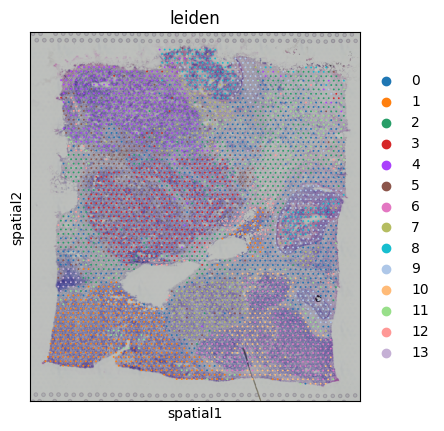

In [19]:
# reduce dims
sc.pp.scale(adata)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10)
sc.tl.umap(adata)
sc.tl.leiden(adata)

sc.pl.spatial(adata, color='leiden', spot_size=100)

/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/merlin/Documents/Programming/the_missing_semester/.ven

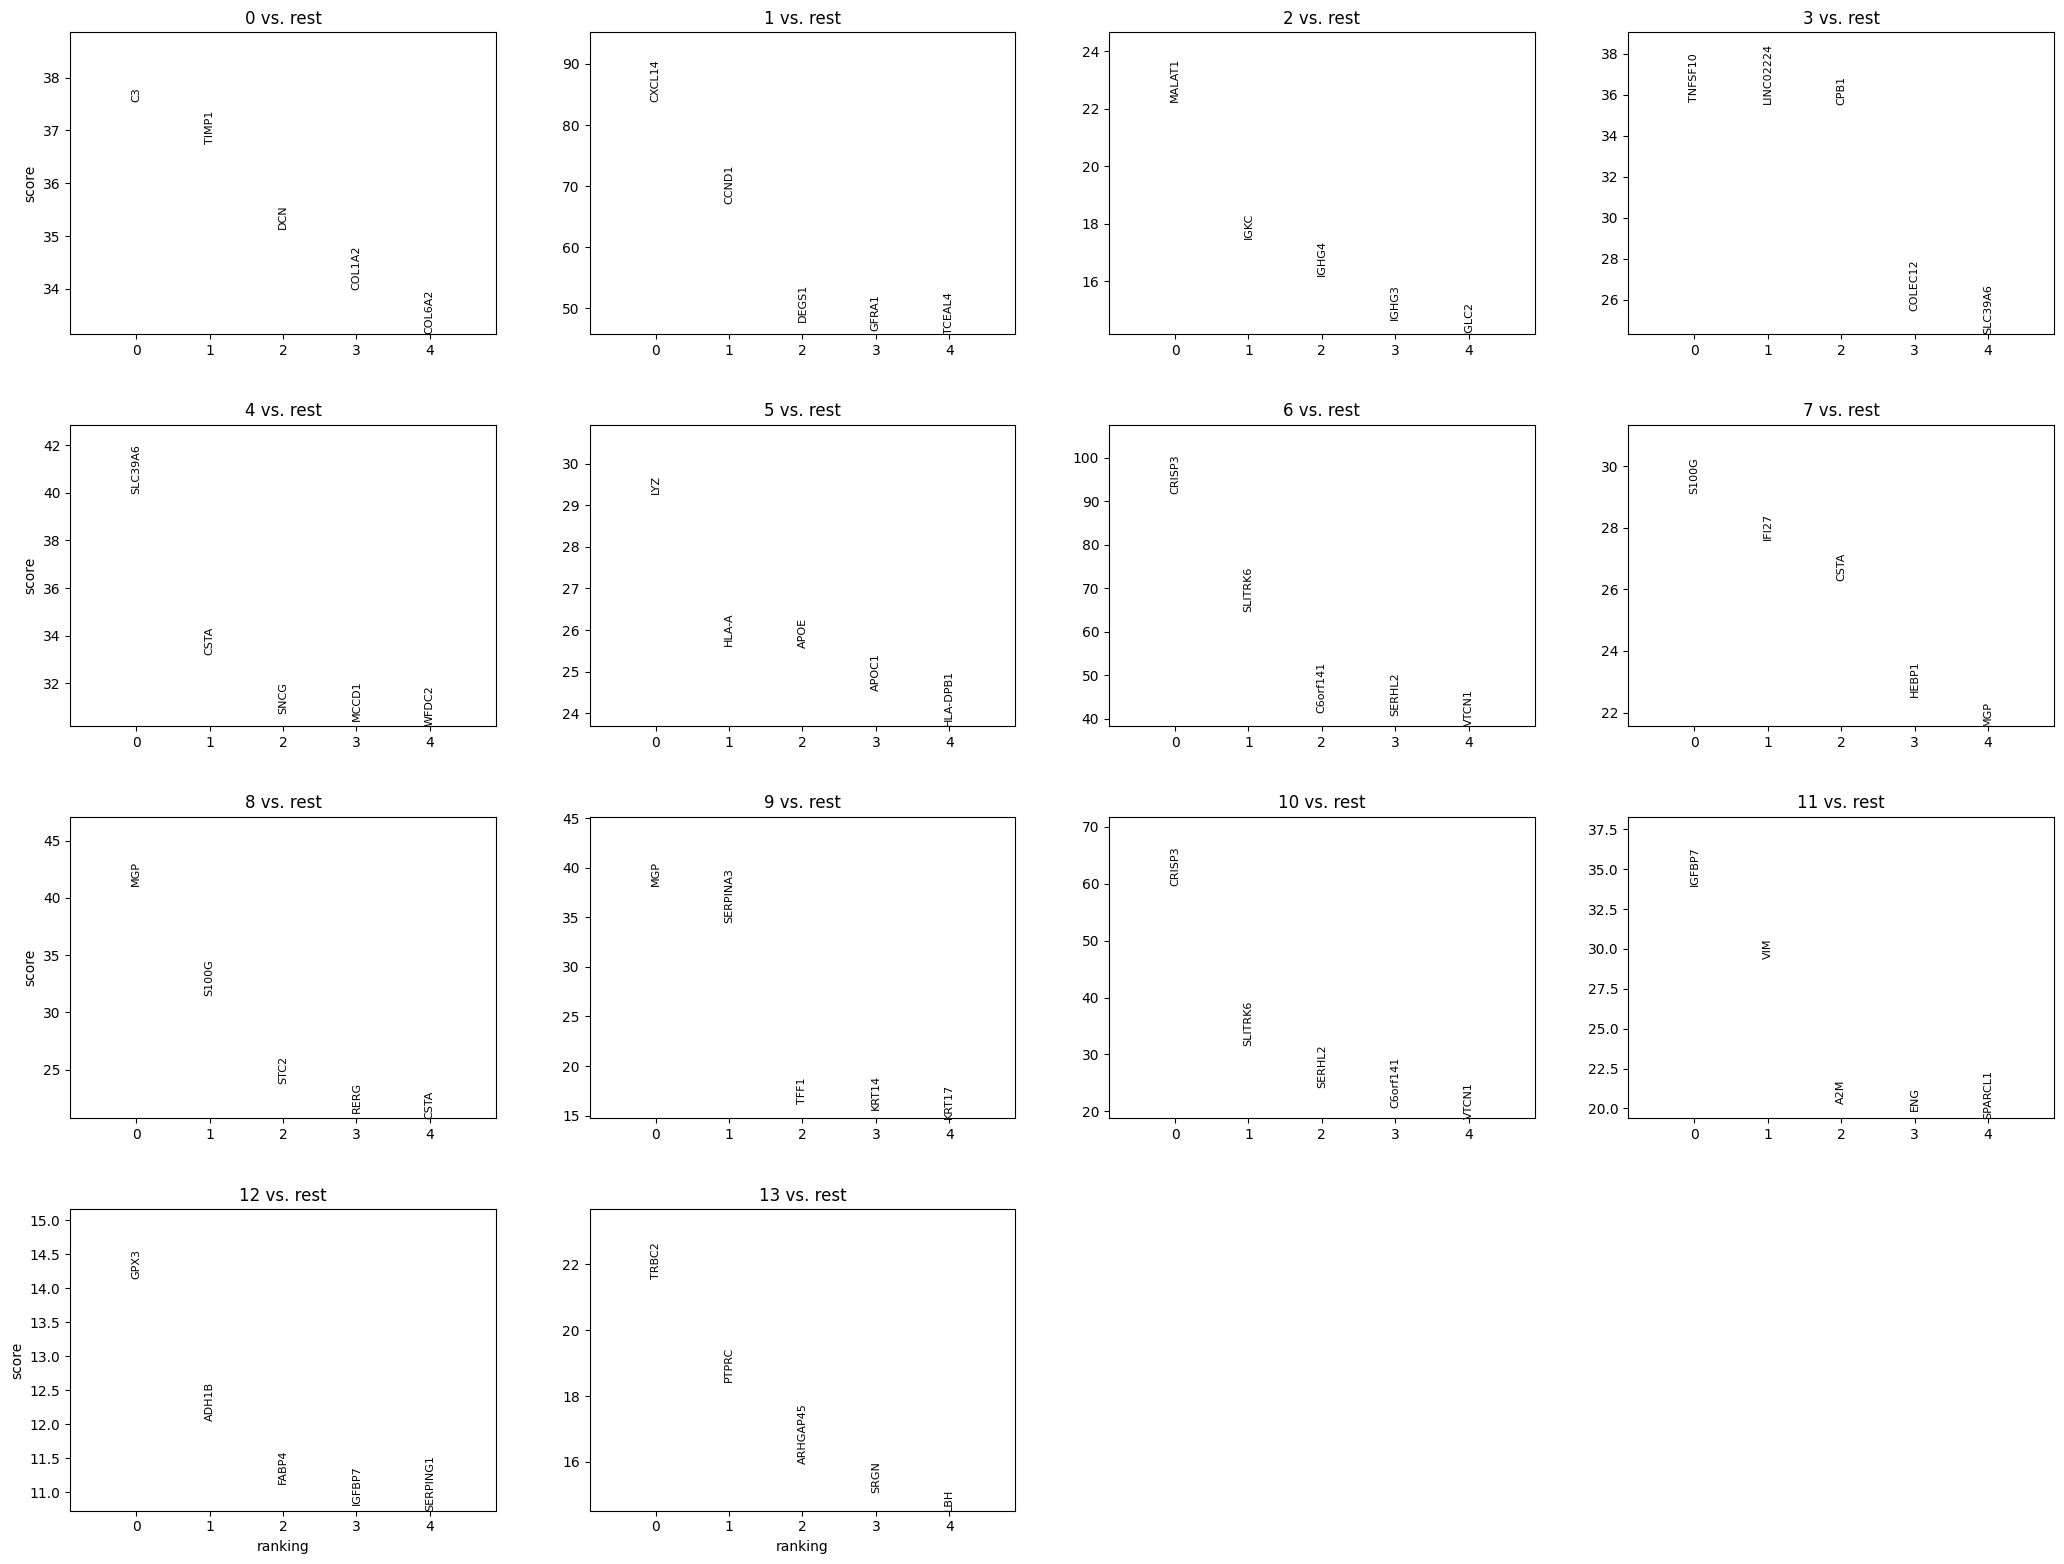

In [20]:
# Identify marker genes
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

In [21]:
# spatial neighborhood enrichment
sq.gr.spatial_neighbors(adata)
sq.gr.spatial_autocorr(adata, mode='moran')

In [22]:
# convert result to df
moran_df = pd.DataFrame(adata.uns['moranI'])

# set gene names as col (instead of index)
moran_df = moran_df.reset_index().rename(columns={"index":"gene"})

# sort by Moran's I value
moran_df_sorted = moran_df.sort_values("I", ascending=False)

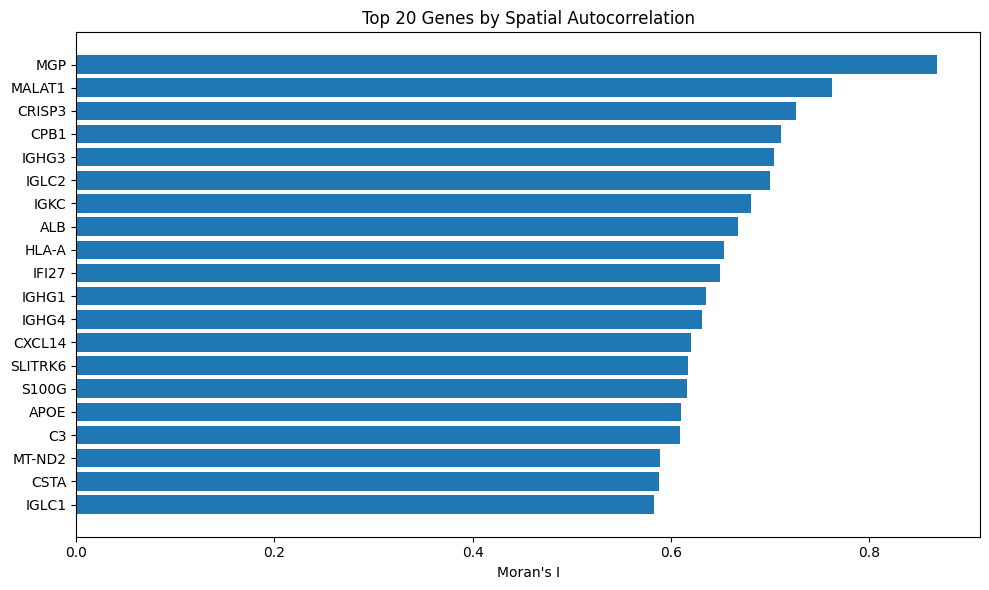

In [23]:
# plot top 20 genes
top_n = 20
plt.figure(figsize=(10,6))
plt.barh(
    moran_df_sorted['gene'][:top_n][::-1], # reverse for descending y-axis
    moran_df_sorted['I'][:top_n][::-1]
)
plt.xlabel("Moran's I")
plt.title(f"Top {top_n} Genes by Spatial Autocorrelation")
plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:00<00:00, 1317.31permutation/s]


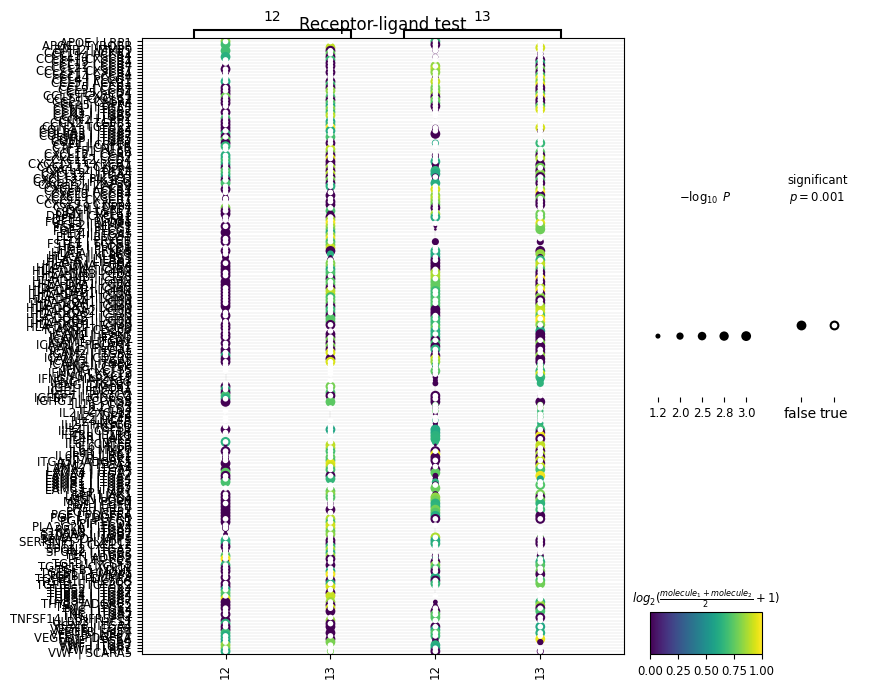

In [24]:
# Find instances where ligand is expressed in one cluster and its receptor in another
sq.gr.ligrec(adata, n_perms=100, cluster_key='leiden', use_raw=False) # n_perms uses 100 permutations, basically random chance or not?

# Plot results
sq.pl.ligrec(adata, cluster_key='leiden', means_range=(0.5,1), figsize=(8, 8))
# Omnipathdb error 'too many 500 error responses'

In [25]:
# Plot only specific clusters
sq.pl.ligrec(
    adata,
    cluster_key='leiden',
    source_groups=['11'],
    target_groups=['12'],
    figsize=(8, 18),
    means_range=(0.5, 1),
)

ValueError: After removing rows with only NaN interactions, none remain.